<a href="https://colab.research.google.com/github/akshaybhatt97/365-DAYS-AI-ML-WITH-AKSHAY/blob/main/day_031_data_leakage.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Day 31/365 — Data Leakage
## How can a model look amazing for the wrong reason?

**Data leakage** happens when information that would not actually be available at prediction time sneaks into model training.

Today we use the real scikit-learn **Diabetes regression dataset** and deliberately create one leaky feature so the problem is easy to see.

We compare:
1. A normal Linear Regression model using legitimate input features
2. The same model after adding a feature derived from the target

The second model may look much better — but for the wrong reason.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

## 1. Load the real dataset

In [2]:
diabetes = load_diabetes(as_frame=True)

X = diabetes.data.copy()
y = diabetes.target.copy()

print("Dataset shape:", X.shape)
print("Features:", X.columns.tolist())
display(X.head())

Dataset shape: (442, 10)
Features: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


## 2. Build a legitimate baseline

We split the original dataset and train Linear Regression using only features that would be available as inputs.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

baseline_model = LinearRegression()
baseline_model.fit(X_train, y_train)

baseline_pred = baseline_model.predict(X_test)

baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
baseline_r2 = r2_score(y_test, baseline_pred)

print("Baseline RMSE:", round(baseline_rmse, 2))
print("Baseline R²:", round(baseline_r2, 3))

Baseline RMSE: 53.85
Baseline R²: 0.453


## 3. Deliberately create target leakage

For learning purposes, we now create a new feature using the **target itself**:

`leaky_feature = target + small_noise`

This is invalid in a real ML pipeline because the target is exactly what we are trying to predict.

At inference time, this feature would not exist.

In [4]:
rng = np.random.default_rng(42)

X_leaky = X.copy()

X_leaky["leaky_feature"] = y + rng.normal(
    loc=0,
    scale=5,
    size=len(y)
)

display(X_leaky.head())

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,leaky_feature
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,152.523585
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,69.800079
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,144.752256
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,210.702824
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,125.244824


## 4. Train the leaky model

We use the same train/test indices so the comparison is fair.

In [5]:
X_leaky_train = X_leaky.loc[X_train.index]
X_leaky_test = X_leaky.loc[X_test.index]

leaky_model = LinearRegression()
leaky_model.fit(X_leaky_train, y_train)

leaky_pred = leaky_model.predict(X_leaky_test)

leaky_rmse = np.sqrt(mean_squared_error(y_test, leaky_pred))
leaky_r2 = r2_score(y_test, leaky_pred)

print("Leaky RMSE:", round(leaky_rmse, 2))
print("Leaky R²:", round(leaky_r2, 3))

Leaky RMSE: 4.76
Leaky R²: 0.996


## 5. Compare the results

,Model,Test RMSE,Test R2
0,Legitimate Features,53.853,0.453
1,With Leaky Feature,4.760,0.996


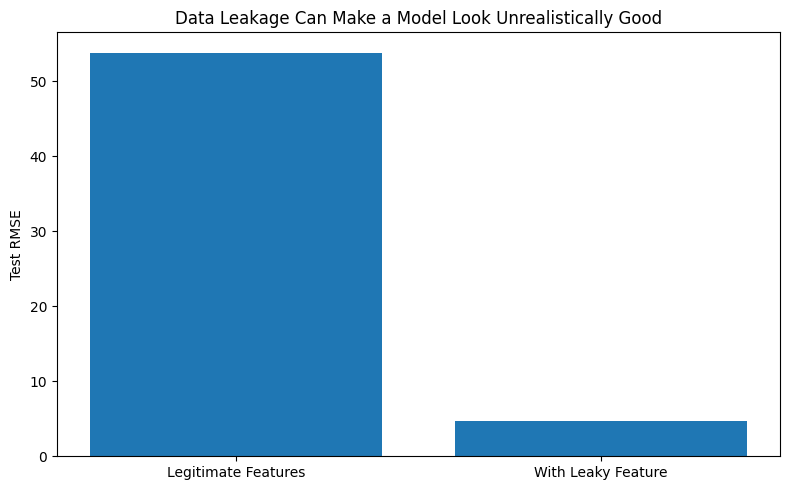

In [6]:
results = pd.DataFrame({
    "Model": [
        "Legitimate Features",
        "With Leaky Feature"
    ],
    "Test RMSE": [
        baseline_rmse,
        leaky_rmse
    ],
    "Test R2": [
        baseline_r2,
        leaky_r2
    ]
})

display(results.round(3))

plt.figure(figsize=(8, 5))
plt.bar(results["Model"], results["Test RMSE"])
plt.ylabel("Test RMSE")
plt.title("Data Leakage Can Make a Model Look Unrealistically Good")
plt.tight_layout()
plt.show()

## Why the leaky model is useless in production

To calculate `leaky_feature`, we already need the target.

So the model appears excellent offline only because it has indirectly been given the answer.

### Common forms of leakage

- **Target leakage:** a feature contains information about the outcome.
- **Train/test contamination:** test-set information influences training or preprocessing.
- **Time leakage:** future information is used to predict an earlier event.

Examples:
- predicting default using a field created only after default occurs
- fitting an imputer or scaler on all data before splitting
- using next month's account balance to predict this month's event

## What does this experiment teach?

- Extremely strong metrics can sometimes be a **warning sign**.
- Ask whether every feature will actually exist at prediction time.
- Keep the test set isolated from training decisions.
- Fit preprocessing steps using training data only.
- For time-based problems, validation must respect time order.

> A model is not useful because it performs well offline. It is useful only if the same information will exist when the prediction is actually made.

## References

- scikit-learn — Common pitfalls and recommended practices: https://scikit-learn.org/stable/common_pitfalls.html
- scikit-learn — Pipelines: https://scikit-learn.org/stable/modules/compose.html#pipeline
- scikit-learn — Diabetes dataset: https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_diabetes.html